# GP Regression with the squared exponential kernel

Consider again the wages dataset that we used in lectures (e.g., Lecture 23). This simple dataset, which comes from the introductory statistics textbook “Statistical Sleuth” by Ramsey and Schafer, contains weekly wages in 1987 for a sample of 25437 males between the ages of 18 and 70 who worked full-time along with their years of education, years of experience, indicator variable for whether they worked near a city, and a code for the region in the US where they worked.

We will fit a Gaussian Process regression to this data using the squared exponential kernel (as opposed to the kernel based on  Integrated Brownian Motion that we used previously). 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
#Load the dataset wagedata.csv
dt = pd.read_csv("wagedata.csv")
print(dt.head(10))
print(dt.shape)

      Region   MetropolitanStatus  Exper  Educ  WeeklyEarnings
0      South  NotMetropolitanArea      8    12          859.71
1    Midwest     MetropolitanArea     30    12          786.73
2       West     MetropolitanArea     31    14         1424.50
3       West     MetropolitanArea     17    16          959.16
4       West     MetropolitanArea      6    12          154.32
5    Midwest     MetropolitanArea     24    17          282.19
6  Northeast     MetropolitanArea     14    12          444.44
7  Northeast     MetropolitanArea     28    12          451.09
8      South     MetropolitanArea     40    12          490.27
9      South     MetropolitanArea      7    16          493.83
(25437, 5)


As before, we want to fit a regression model with logarithm of weekly earnings as the response variable:
\begin{align*}
   y = \log \left( \text{weekly earnings} \right)
\end{align*}
and years of experience as the covariate: 
\begin{align*}
   x = \text{Exper} = \text{Years of Experience}.
\end{align*}
The following is the scatter plot between $y$ and $x$. 

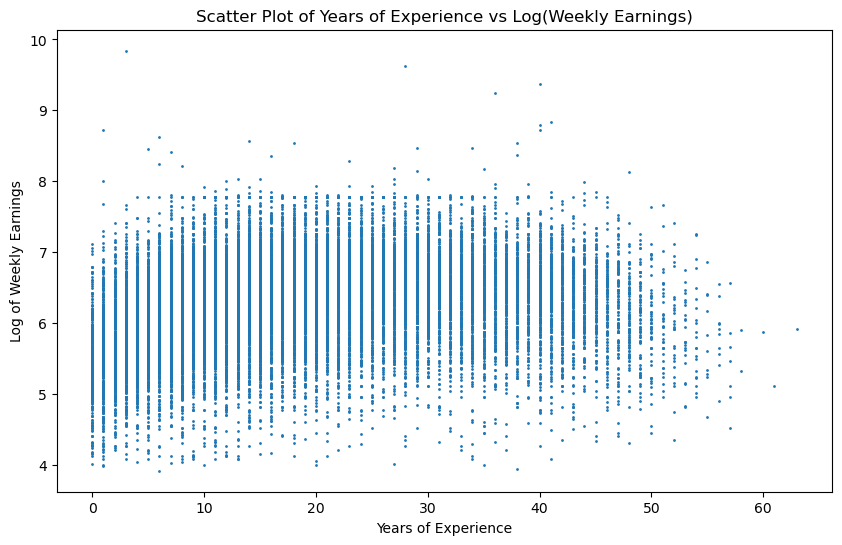

In [4]:
import numpy as np
y = np.log(dt['WeeklyEarnings'])
x = dt['Exper'].to_numpy()
import matplotlib.pyplot as plt
plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 1)
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('Scatter Plot of Years of Experience vs Log(Weekly Earnings)')
plt.show()

Running the GP on the full data might be computationally expensive, so, to illustrate the main ideas without going to computational efficiency considerations, let us work with a smaller dataset.

In [5]:
#Repeating the analysis on a smaller dataset: 
n = 500
random_seed = 42
dt_small = dt.sample(n = 500, random_state = random_seed)
#dt_small = dt #this is to switch back to the full dataset
y = np.log(dt_small['WeeklyEarnings'])
x = dt_small['Exper'].to_numpy()
n = len(y)


Our regression model is: 
\begin{align*}
   y_i = f(x_i) + \epsilon_i 
\end{align*}
where $\epsilon_i \overset{\text{i.i.d}}{\sim} N(0, \sigma^2)$. For $f$, we use the Gaussian process with mean zero and covariance kernel $K(\cdot, \cdot)$. For the covariance kernel, we use the squared exponential kernel, also known as the Radial  Basis Function (RBF) kernel, which is given by: 
\begin{align*}
   K(u, v) = \tau^2 \exp \left(-\frac{(u - v)^2}{2 \ell^2} \right). 
\end{align*}
This kernel has two hyperparameters $\tau$ and $\ell$. Here $\tau$ controls the overall size (also known as amplitude) of the fluctuations of $f$ around its mean (which is zero). Larger values of $\tau$ allow the regression function to vary more widely. The parameter $\ell$ is called the length-scale and controls the smoothness of the sample paths: when $\ell$ is large, the function $f(x)$ changes slowly with $x$, while smaller values of $\ell$ allow more rapid local variation. Thus $\tau$ governs the overall magnitude of variation, where $\ell$ determines how quickly the function can change with the input. 


The following function implements the RBF kernel. 

In [6]:
def rbf_kernel(x1, x2, tau2, ell):
    x1 = x1[:,None]
    x2 = x2[None,:]
    return tau2 * np.exp(-(x1-x2)**2/(2*ell**2))

Given fixed values of $\tau, \ell, \sigma$, the posterior mean of $f(x)$ is: 
\begin{align*}
  \widehat{f(x)} = \mathbf{k}^TK^{-1} (f(x_1), \dots, f(x_n))^T. 
\end{align*}
where $K = (K(x_i, 
                                             x_j))_{n \times n}$ and
                                             $\mathbf{k} = (K(x_i,
                                                            x))_{n
                                                            \times
                                                            1}$. 
The following code computes the posterior mean of $f(x)$ for a grid of $x$ values.                                                             

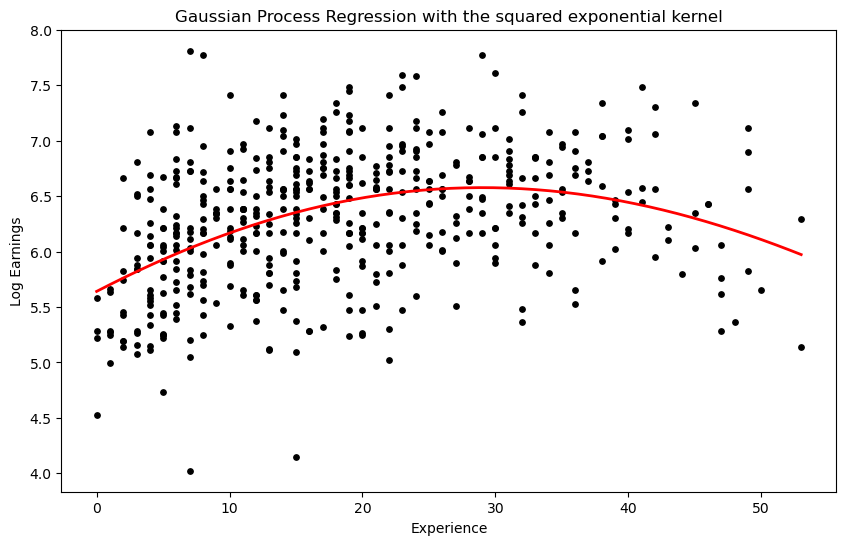

In [7]:
#Here are some arbitrary choices for tau^2, \ell, \sigma^2: 
tau2 = 14
ell = 70
sigma2 = 0.3 

K = rbf_kernel(x,x,tau2,ell) + sigma2*np.eye(n)
Kinv = np.linalg.inv(K)

x_grid = np.linspace(min(x),max(x),200)

K_star = rbf_kernel(x_grid,x,tau2,ell)

post_mean = K_star @ Kinv @ y

plt.figure(figsize=(10,6))
plt.scatter(x,y, s = 15, color = 'black')
plt.plot(x_grid,post_mean,color='red',lw=2)
plt.xlabel('Experience')
plt.ylabel('Log Earnings')
plt.title('Gaussian Process Regression with the squared exponential kernel')
plt.show()

The posterior mean gives a smooth fitted function. Let us now change the parameter values and plot the posterior mean of $f(x)$. 

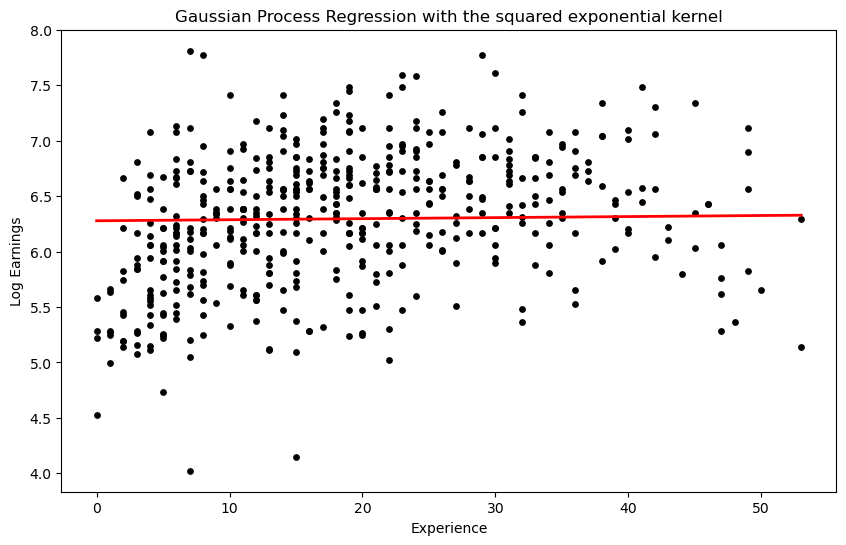

In [8]:
#Here are some arbitrary choices for tau^2, \ell, \sigma^2: 
tau2 = 14
ell = 7000 #this change to 7000 will make the fit much smoother, since the kernel will be much less sensitive to differences in x values.
sigma2 = 0.3 

K = rbf_kernel(x,x,tau2,ell) + sigma2*np.eye(n)
Kinv = np.linalg.inv(K)

x_grid = np.linspace(min(x),max(x),200)

K_star = rbf_kernel(x_grid,x,tau2,ell)

post_mean = K_star @ Kinv @ y

plt.figure(figsize=(10,6))
plt.scatter(x,y, s = 15, color = 'black')
plt.plot(x_grid,post_mean,color='red',lw=2)
plt.xlabel('Experience')
plt.ylabel('Log Earnings')
plt.title('Gaussian Process Regression with the squared exponential kernel')
plt.show()

Note that we are not using a parameter for the mean. In other words, our model is NOT $f(x) = \beta_0 + g(x)$ where $g$ is the GP with RBF kernel. Because of this, if we set $\tau$ too small, then the fitted function will basically be zero, and will present a poor fit to the data. 

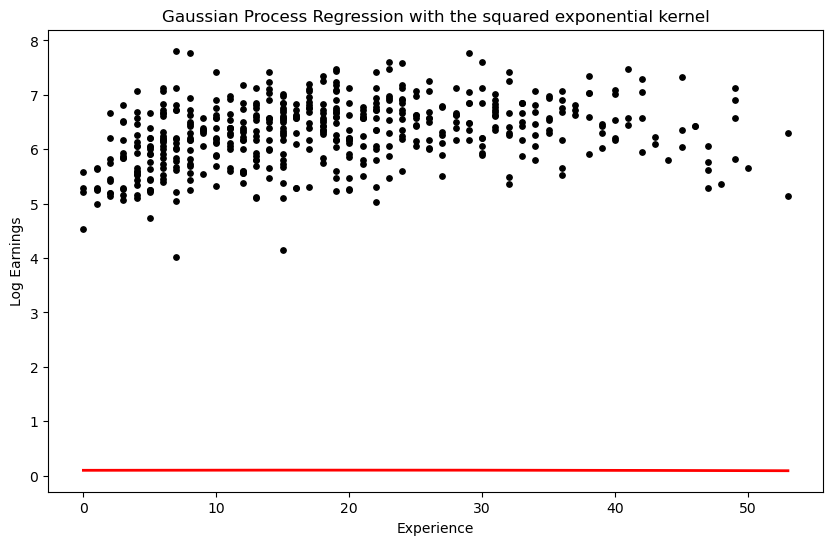

In [9]:
#Here are some arbitrary choices for tau^2, \ell, \sigma^2: 
tau2 = 0.00001 #for such a small value of tau^2, the fit will basically equal zero. 
ell = 70 
sigma2 = 0.3 

K = rbf_kernel(x,x,tau2,ell) + sigma2*np.eye(n)
Kinv = np.linalg.inv(K)

x_grid = np.linspace(min(x),max(x),200)

K_star = rbf_kernel(x_grid,x,tau2,ell)

post_mean = K_star @ Kinv @ y

plt.figure(figsize=(10,6))
plt.scatter(x,y, s = 15, color = 'black')
plt.plot(x_grid,post_mean,color='red',lw=2)
plt.xlabel('Experience')
plt.ylabel('Log Earnings')
plt.title('Gaussian Process Regression with the squared exponential kernel')
plt.show()

In practice, the hyperparameters need to be tuned based on the data. For this, the simplest method is to write down the marginal likelihood of $y_1, \dots, y_n$ (marginal here means that the function $f(x)$ is integrated out), and then to maximize the marginal likelihood over the hyperparameters. The marginal likelihood is given by: 
\begin{align*}
  f_{y \mid \sigma, \tau, \ell}(y) \propto \frac{1}{\sqrt{\det(K +
  \sigma^2 I_n)}} \exp \left(-\frac{1}{2} y^T (K + \sigma^2 I_n)^{-1}
  y \right). 
\end{align*}
where $y = (y_1, \dots, y_n)$. Note that $K$ depends on $\tau$ and $\ell$.  

Below we optimize $\log f_{y \mid \sigma, \tau, \ell}(y)$ over $\sigma, \tau, \ell$. We take a grid based approach which is time consuming (and will be infeasible if we run the method on the whole dataset with size around 25K). 


In [10]:
#we are using Cholesky decomposition to compute the log marginal likelihood in a more numerically stable way.
def log_marginal_likelihood(x,y,tau2,ell,sigma2):

    K = rbf_kernel(x,x,tau2,ell)
    K = K + sigma2*np.eye(len(x))

    L = np.linalg.cholesky(K)

    alpha = np.linalg.solve(L.T,
            np.linalg.solve(L,y))

    logdet = 2*np.sum(np.log(np.diag(L)))

    return -0.5*y@alpha -0.5*logdet -0.5*len(x)*np.log(2*np.pi)

In [11]:
tau_grid = np.logspace(-2,2,20)
ell_grid = np.logspace(-1,2,20)
sig_grid = np.logspace(-3,0,20)

best_val = -np.inf
best_params = None

for tau2 in tau_grid:
    for ell in ell_grid:
        for sigma2 in sig_grid:

            val = log_marginal_likelihood(x,y,tau2,ell,sigma2)

            if val > best_val:
                best_val = val
                best_params = (tau2,ell,sigma2)

print(best_params)

(np.float64(14.38449888287663), np.float64(69.51927961775606), np.float64(0.3359818286283781))


In [14]:
tau2, ell, sigma2 = best_params

K = rbf_kernel(x,x,tau2,ell) + sigma2*np.eye(n)
Kinv = np.linalg.inv(K)

x_grid = np.linspace(min(x),max(x),200)

K_star = rbf_kernel(x_grid,x,tau2,ell)

post_mean = K_star @ Kinv @ y

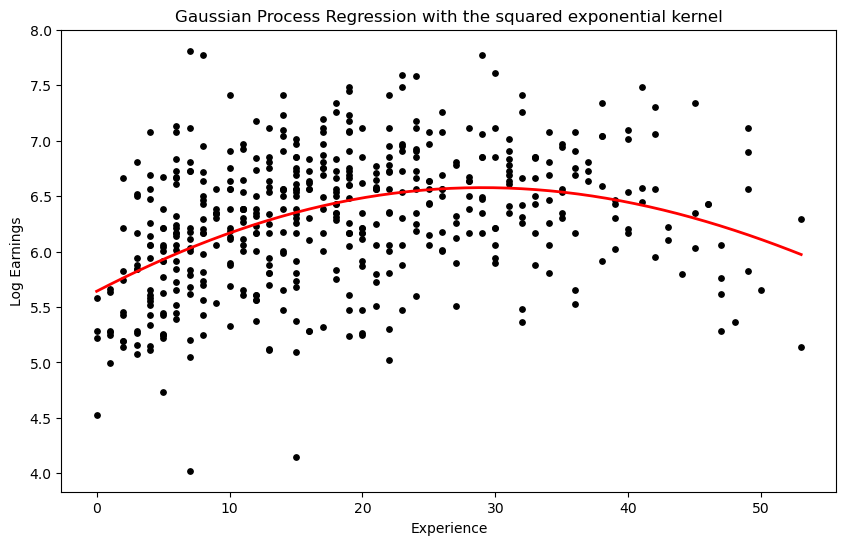

In [15]:
plt.figure(figsize=(10,6))
plt.scatter(x,y, s = 15, color = 'black')
plt.plot(x_grid,post_mean,color='red',lw=2)
plt.xlabel('Experience')
plt.ylabel('Log Earnings')
plt.title('Gaussian Process Regression with the squared exponential kernel')
plt.show()

Instead of gridding, we can using inbuilt optimization routines in scipy. This makes the code much faster. 

In [16]:
from scipy.optimize import minimize

def rbf_kernel(x1, x2, tau2, ell):
    x1 = np.asarray(x1).reshape(-1, 1)
    x2 = np.asarray(x2).reshape(-1, 1)
    sqdist = (x1 - x2.T) ** 2
    return tau2 * np.exp(-sqdist / (2 * ell**2))

def log_marginal_likelihood(x, y, tau2, ell, sigma2):
    n = len(x)
    K = rbf_kernel(x, x, tau2, ell)
    K = K + sigma2 * np.eye(n)

    # small jitter for numerical stability
    K = K + 1e-8 * np.eye(n)

    L = np.linalg.cholesky(K)

    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
    logdet = 2 * np.sum(np.log(np.diag(L)))

    return -0.5 * y @ alpha - 0.5 * logdet - 0.5 * n * np.log(2 * np.pi)

def objective(log_params, x, y):
    log_tau2, log_ell, log_sigma2 = log_params

    tau2 = np.exp(log_tau2)
    ell = np.exp(log_ell)
    sigma2 = np.exp(log_sigma2)

    # minimize negative log marginal likelihood
    return -log_marginal_likelihood(x, y, tau2, ell, sigma2)

# initial guess
init = np.log([1.0, 1.0, 0.1])

# optional bounds in log-space
bounds = [
    (np.log(1e-4), np.log(1e4)),   # tau2
    (np.log(1e-3), np.log(1e3)),   # ell
    (np.log(1e-6), np.log(1e1))    # sigma2
]

result = minimize(
    objective,
    init,
    args=(x, y),
    method="L-BFGS-B",
    bounds=bounds
)

best_log_tau2, best_log_ell, best_log_sigma2 = result.x
best_params_lbfgs = (
    np.exp(best_log_tau2),
    np.exp(best_log_ell),
    np.exp(best_log_sigma2)
)

print("Best parameters:", best_params_lbfgs)

Best parameters: (np.float64(19.49622536763746), np.float64(72.1825467002777), np.float64(0.29899253407560966))


In [17]:
tau2, ell, sigma2 = best_params_lbfgs

K = rbf_kernel(x,x,tau2,ell) + sigma2*np.eye(n)
Kinv = np.linalg.inv(K)

x_grid = np.linspace(min(x),max(x),200)

K_star = rbf_kernel(x_grid,x,tau2,ell)

post_mean_lbfgs = K_star @ Kinv @ y

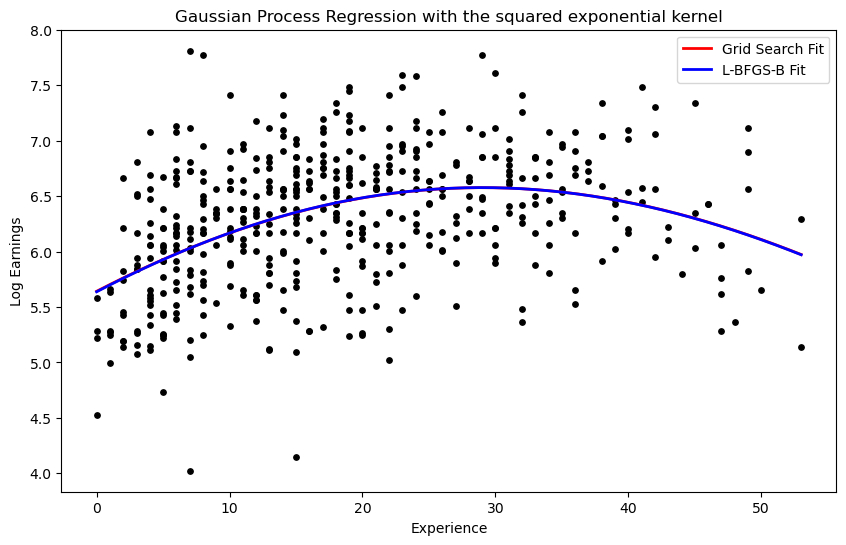

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(x,y, s = 15, color = 'black')
plt.plot(x_grid,post_mean,color='red',lw=2, label='Grid Search Fit')
plt.plot(x_grid,post_mean_lbfgs,color='blue',lw=2, label='L-BFGS-B Fit')
plt.xlabel('Experience')
plt.ylabel('Log Earnings')
plt.legend()
plt.title('Gaussian Process Regression with the squared exponential kernel')
plt.show()

In [19]:
print(np.column_stack([post_mean_lbfgs, post_mean]))


[[5.63709283 5.64158245]
 [5.65373462 5.65801332]
 [5.67024647 5.67431908]
 [5.68662765 5.69049895]
 [5.70287744 5.70655216]
 [5.7189951  5.72247793]
 [5.73497993 5.7382755 ]
 [5.75083122 5.75394411]
 [5.76654826 5.769483  ]
 [5.78213036 5.78489144]
 [5.79757685 5.80016869]
 [5.81288704 5.81531403]
 [5.82806026 5.83032672]
 [5.84309586 5.84520607]
 [5.85799317 5.85995136]
 [5.87275156 5.8745619 ]
 [5.88737038 5.889037  ]
 [5.901849   5.90337598]
 [5.91618681 5.91757817]
 [5.93038318 5.93164289]
 [5.94443752 5.9455695 ]
 [5.95834922 5.95935734]
 [5.97211769 5.97300578]
 [5.98574235 5.98651418]
 [5.99922264 5.99988191]
 [6.01255797 6.01310837]
 [6.0257478  6.02619294]
 [6.03879158 6.03913502]
 [6.05168877 6.05193403]
 [6.06443884 6.06458937]
 [6.07704125 6.07710049]
 [6.08949551 6.0894668 ]
 [6.10180109 6.10168776]
 [6.11395751 6.11376281]
 [6.12596427 6.12569142]
 [6.13782089 6.13747306]
 [6.14952691 6.14910721]
 [6.16108186 6.16059334]
 [6.17248527 6.17193096]
 [6.18373672 6.18311958]


Clearly the two fits are very nearly the same. Let us now change the prior on $f(x)$ to: 
\begin{align*}
   f(x) = \beta_0 + g(x)
\end{align*}
where $g$ now has the aforementioned squared exponential kernel. We can treate $\beta_0$ also as a hyperparameter and estimate it by maximizing the marginal likelihood. 

In [20]:
def rbf_kernel(x1, x2, tau2, ell):
    x1 = np.asarray(x1).reshape(-1, 1)
    x2 = np.asarray(x2).reshape(-1, 1)
    sqdist = (x1 - x2.T) ** 2
    return tau2 * np.exp(-sqdist / (2 * ell**2))

def log_marginal_likelihood(x, y, beta0, tau2, ell, sigma2):
    n = len(x)

    K = rbf_kernel(x, x, tau2, ell) + sigma2 * np.eye(n)
    K = K + 1e-8 * np.eye(n)   # jitter for numerical stability

    yc = y - beta0             # center by the mean parameter

    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, yc))
    logdet = 2 * np.sum(np.log(np.diag(L)))

    return -0.5 * yc @ alpha - 0.5 * logdet - 0.5 * n * np.log(2 * np.pi)

def objective(params, x, y):
    beta0, log_tau2, log_ell, log_sigma2 = params

    tau2 = np.exp(log_tau2)
    ell = np.exp(log_ell)
    sigma2 = np.exp(log_sigma2)

    return -log_marginal_likelihood(x, y, beta0, tau2, ell, sigma2)

# initial guess
init = np.array([
    np.mean(y),        # beta0
    np.log(1.0),       # tau2
    np.log(1.0),       # ell
    np.log(0.1)        # sigma2
])

bounds = [
    (None, None),                  # beta0 can be any real number
    (np.log(1e-4), np.log(1e4)),   # tau2
    (np.log(1e-3), np.log(1e3)),   # ell
    (np.log(1e-6), np.log(1e1))    # sigma2
]

result = minimize(
    objective,
    init,
    args=(x, y),
    method="L-BFGS-B",
    bounds=bounds
)

beta0_hat = result.x[0]
tau2_hat = np.exp(result.x[1])
ell_hat = np.exp(result.x[2])
sigma2_hat = np.exp(result.x[3])

best_params_lbfgs_beta0 = (beta0_hat, tau2_hat, ell_hat, sigma2_hat)

print("Best parameters (beta0, tau2, ell, sigma2):", best_params_lbfgs_beta0)

Best parameters (beta0, tau2, ell, sigma2): (np.float64(5.879643451687931), np.float64(0.3424475854385845), np.float64(14.032516835084214), np.float64(0.29735067195655634))


Note now that the estimates of $\tau$ and $\ell$ change quite significantly compared to before. Below we compute the posterior mean of $f(x)$ in this model. We are simply subtracting $\beta_0$ from $y$ to get $y - \beta_0$, then computing the posterior mean as before, and then adding back $\beta_0$. 

In [21]:
n = len(x)

beta0, tau2, ell, sigma2 = best_params_lbfgs_beta0

K = rbf_kernel(x, x, tau2, ell) + sigma2 * np.eye(n)
Kinv = np.linalg.inv(K)

x_grid = np.linspace(np.min(x), np.max(x), 200)

K_star = rbf_kernel(x_grid, x, tau2, ell)

post_mean_lbfgs_beta0 = beta0 + K_star @ Kinv @ (y - beta0)

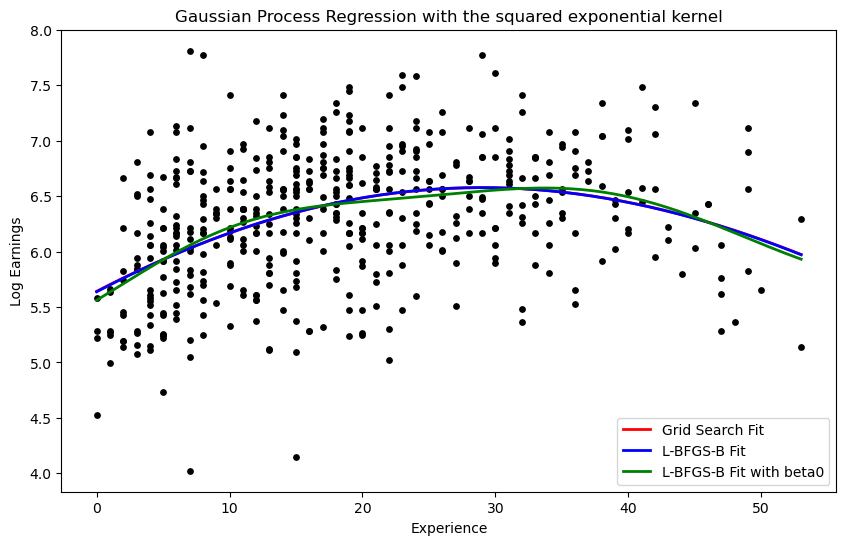

In [22]:
plt.figure(figsize=(10,6))
plt.scatter(x,y, s = 15, color = 'black')
plt.plot(x_grid,post_mean,color='red',lw=2, label='Grid Search Fit')
plt.plot(x_grid,post_mean_lbfgs,color='blue',lw=2, label='L-BFGS-B Fit')
plt.plot(x_grid,post_mean_lbfgs_beta0,color='green',lw=2, label='L-BFGS-B Fit with beta0')
plt.xlabel('Experience')
plt.ylabel('Log Earnings')
plt.legend()
plt.title('Gaussian Process Regression with the squared exponential kernel')
plt.show()

Let us now compare this estimate with that obtained from the Integrated Brownian Motion prior that we used in Lecture 23. The value of $\gamma$ below was obtained by posterior inference on $\gamma$ from Lecture 23. 

In [35]:
gamma = 0.0278 #this value was suggested by posterior inference over gamma (see code for Lecture 23)
X = np.column_stack((np.ones(n), x)) #usual X matrix for linear regression

def K_I(u, v):
    minuv = min(u, v)
    maxuv = max(u, v)
    return (minuv**2 / 6.0) * (3*maxuv - minuv)

K_ibm = np.array([[K_I(xi, xj) for xj in x] for xi in x])

# grid
M = np.max(x)
grid_f = x_grid
kvec  = np.array([[K_I(u, xi) for xi in x] for u in grid_f])

# A_gamma
A_gamma = np.eye(n) + gamma**2 * K_ibm
A_gamma_inv = np.linalg.inv(A_gamma)

#the X^T A_gamma^-1 X and its inverse
XtAinvX = X.T @ A_gamma_inv @ X
XtAinvX_inv = np.linalg.inv(XtAinvX)

# the matrix P (defined above)
P = A_gamma_inv - A_gamma_inv @ X @ XtAinvX_inv @ X.T @ A_gamma_inv

# Offset term:
alpha = XtAinvX_inv  @ X.T @ A_gamma_inv @ y

# all the vectors (1, u) stacked together for all u in grid_f
H = np.column_stack((np.ones(len(grid_f)), grid_f))

# posterior mean
post_mean_ibm = H @ alpha + gamma**2 * kvec @ (P @ y)

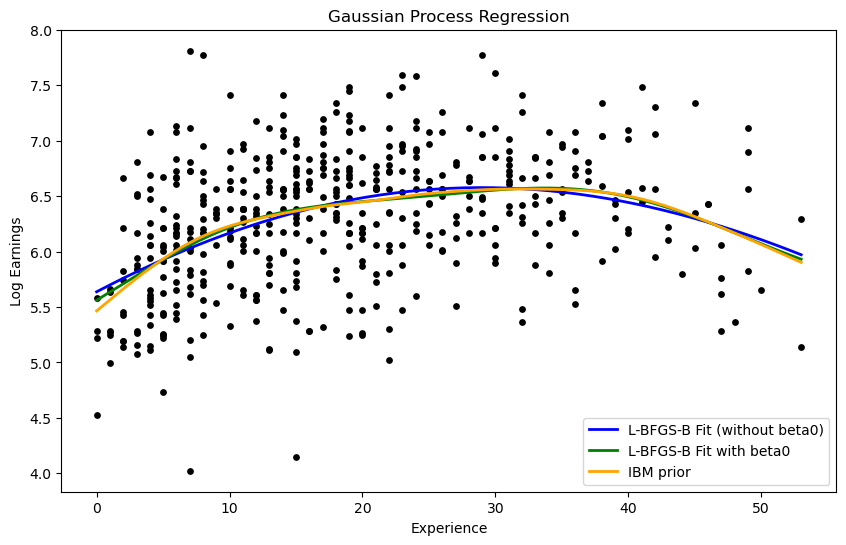

In [36]:
plt.figure(figsize=(10,6))
plt.scatter(x,y, s = 15, color = 'black')
#plt.plot(x_grid,post_mean,color='red',lw=2, label='Grid Search Fit')
plt.plot(x_grid,post_mean_lbfgs,color='blue',lw=2, label='L-BFGS-B Fit (without beta0)')
plt.plot(x_grid,post_mean_lbfgs_beta0,color='green',lw=2, label='L-BFGS-B Fit with beta0')
plt.plot(x_grid,post_mean_ibm,color='orange',lw=2, label='IBM prior')
plt.xlabel('Experience')
plt.ylabel('Log Earnings')
plt.legend()
plt.title('Gaussian Process Regression')
plt.show()

These estimates all look quite similar. 